# Least squares approximation

## Introduction to Least Squares and the Normal Equation

The **Least Squares** method is a fundamental approach in regression analysis used to find the best-fitting curve or
line to a given set of data points by minimizing the sum of the squares of the vertical deviations (residuals) from each
data point to the curve. This technique is widely used in data fitting, statistics, and machine learning.

### Discrete Case
Given a set of observed data points $(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)$, we aim to find a function $y = g(x)$ from a
chosen family of functions that best approximates the data. The least squares method seeks the function $g$ that minimizes the
sum of the squared differences between the observed values $y_i$ and the predicted values $g(x_i)$, where $g(x)$ is expressed as a
linear combination of $m$ basis functions, $\{\phi_j(x)\}$:

$$
g(x) = \sum_{j=0}^m a_j \phi_j(x).
$$


Given the data points, we can express the problem in matrix form:
$$
\underline{\bf y} = A \underline{\bf a}
$$
where
$$
A=\begin{bmatrix}
\phi_0(x_1) & \phi_1(x_1) & \cdots & \phi_m(x_1) \\
\phi_0(x_2) & \phi_1(x_2) & \cdots & \phi_m(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_0(x_n) & \phi_1(x_n) & \cdots & \phi_m(x_n)
\end{bmatrix},
$$
$$
\underline{\bf a} = \begin{bmatrix}
a_0 \\
a_1 \\
\vdots \\
a_m
\end{bmatrix}
$$
and
$$
\underline{\bf y} = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}.
$$

Here, $\{\phi_j(x)\}$ are the chosen basis functions (such as polynomials, sines, cosines, etc.), and $a_j$ are the coefficients
to be determined.
The problem is to find the coefficients $a_j$ that minimize the sum of squared residuals:
$$
\min_{\bf a} \sum_{i=1}^n (y_i - g(x_i))^2  = \min_{\bf a}({\bf y}-A{\bf a})^T({\bf y}-A{\bf a})
$$
where
$$
A{\bf a} = \begin{bmatrix}
g(x_1) \\
g(x_2) \\
\vdots \\
g(x_n)
\end{bmatrix}
$$

Setting the gradient with respect to ${\bf a}$ to zero,
$$
\nabla_{\bf a}\,({\bf y}-A{\bf a})^T({\bf y}-A{\bf a}) = -2A^T({\bf y}-A{\bf a}) = {\bf 0},
$$
leads to the _normal equation_:
$$
A^T A \underline{\bf a} = A^T \underline{\bf y}
$$
Geometrically: the residual ${\bf y}-A{\bf a}$ is orthogonal to every column of $A$, i.e. $A{\bf a}$ is the orthogonal projection of ${\bf y}$ onto the column space of $A$.

**Note:** the condition number of $A^TA$ is the square of that of $A$, $\kappa(A^TA)=\kappa(A)^2$. Solving the normal equations can therefore lose twice as many digits as necessary; in practice one uses QR-based solvers such as `np.linalg.lstsq`.

**Example**
If the basis functions are polynomials of increasing power:
$$
g(x)= a_0+a_1 x+a_2 x^2 + \ldots a_m x^m
$$
with $\phi_k(x) = x^{k}$ for $k=0,1,\ldots,m$.
Now the matrix $A$ becomes the (**Vandermonde matrix**):
$$
A= \begin{bmatrix}
    1 & x_1 & \cdots & x_1^m \\
    1 & x_2 & \cdots & x_2^m \\
    \vdots & \vdots & \ddots & \vdots \\
    1 & x_n & \cdots & x_n^m
\end{bmatrix}.
$$


### Continuous Case
In the continuous case, we consider a function $f(x)$ defined over a continuous domain, $x\in[a,b]$.
The goal remains the same, but the sum over data points is replaced by an integral:
we seek the $g$ that minimizes the integrated squared error between $f$ and $g$.

We can express the continuous version of the least squares problem as:

$$
\min_{\bf a} \int_a^b (f(x) - g(x,{\bf a}))^2 \, dx
$$


#### The Normal Equation for continuous case

To derive the normal equation, we start with the least squares objective function:
$$
J({\bf a}) = \int_a^b (f(x) - g(x,{\bf a}))^2 \, dx
$$
on component form:
$$
J({\bf a}) = \int_a^b (f(x) - g(x,{\bf a}))^2 \, dx = \int_a^b (f(x) - \sum_{j=0}^m a_j \phi_j(x))^2 \, dx
$$
The partial derivative of $J({\bf a})$ with respect to each coefficient $a_k$ is set to zero to find the minimum:
$$
\frac{\partial J({\bf a})}{\partial a_k} = \int_a^b 2(f(x) - \sum_{j=0}^m a_j \phi_j(x))(-\phi_k(x)) \, dx = -2 \int_a^b f(x)\phi_k(x) \, dx + 2 \sum_{j=0}^m a_j \int_a^b   \phi_j(x)\phi_k(x) \, dx = -2 b_k + 2 \sum_{j=0}^m a_j g_{jk} = 0
$$
where
$$
b_k = \int_a^b f(x)\phi_k(x) \, dx, \quad g_{jk} = \int_a^b \phi_j(x)\phi_k(x) \, dx
$$
giving the equations:
$$
\sum_{j=0}^m a_j g_{jk} = b_k, \quad k=0,\ldots,m
$$
or on matrix form:
$$
\underline{\bf G} \underline{\bf a} = \underline{\bf b}
$$
where
$$
\underline{\bf G} = \begin{bmatrix}
g_{00} & g_{01} & \cdots & g_{0m} \\
g_{10} & g_{11} & \cdots & g_{1m} \\
\vdots & \vdots & \ddots & \vdots \\
g_{m0} & g_{m1} & \cdots & g_{mm}
\end{bmatrix}, \quad
\underline{\bf a} = \begin{bmatrix}
a_0 \\
a_1 \\
\vdots \\
a_m
\end{bmatrix}, \quad
\underline{\bf b} = \begin{bmatrix}
b_0 \\
b_1 \\
\vdots \\
b_m
\end{bmatrix}
$$

Notice that $\underline{\bf G}$ (the _Gram matrix_ of the basis) is symmetric, i.e., $g_{jk} = g_{kj}$.
If the basis functions are _orthogonal_, $g_{jk}=0$ for $j\neq k$, then $\underline{\bf G}$ is diagonal and the system is trivial to solve (and well conditioned if the basis functions have similar norms).

# Discrete example from Turner
Table 4.1 from Turner et al. Driving at the specified speed, this shows the distance the car traveled after the driver was told to stop.

| Speed (km/h) | Distance (m) |
|--------------|-------------|
| 40           | 17          |
| 55           | 31          |
| 70           | 46          |
| 90           | 65          |
| 100          | 87          |

We fit a second order polynomial $g(x)=a_0+a_1x+a_2x^2$.

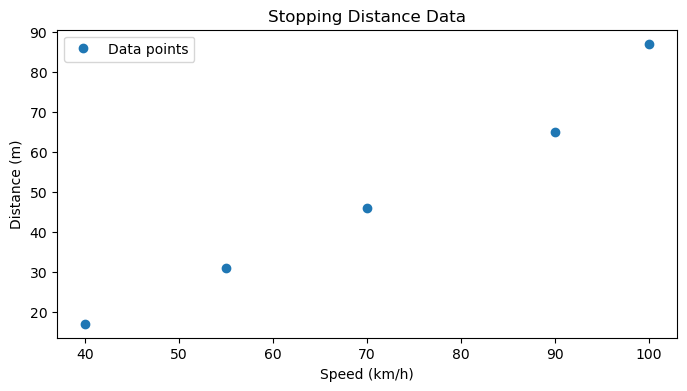

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Data from the table
speed = np.array([40, 55, 70, 90, 100])
distance = np.array([17, 31, 46, 65, 87])

# Plotting the results
plt.figure(figsize=(8, 4))
plt.plot(speed, distance, 'o', label='Data points')
plt.xlabel('Speed (km/h)')
plt.ylabel('Distance (m)')
plt.title('Stopping Distance Data')
plt.legend()
plt.show()

In [ ]:


# Construct A matrix for second order polynomial: [1, speed, speed^2]
A = np.column_stack([np.ones_like(speed), speed, speed**2])
y_vec = distance

print("A matrix:\n", A)
print("y vector:\n", y_vec)

A matrix:
 [[    1    40  1600]
 [    1    55  3025]
 [    1    70  4900]
 [    1    90  8100]
 [    1   100 10000]]
y vector:
 [17 31 46 65 87]


In [2]:
# Solve the normal equation A^T A a = A^T y
ATA = A.T @ A
ATy = A.T @ y_vec
coeffs = np.linalg.solve(ATA, ATy)   # prefer solve over inv(ATA) @ ATy
print("LSQ polynomial coefficients (normal eq.):", coeffs)

# Library routine (QR/SVD based, never forms A^T A)
coeffs_lstsq, *_ = np.linalg.lstsq(A, y_vec, rcond=None)
print("LSQ polynomial coefficients (lstsq):     ", coeffs_lstsq)

print(f"cond(A)     = {np.linalg.cond(A):.1e}")
print(f"cond(A^T A) = {np.linalg.cond(ATA):.1e}   (= cond(A)^2)")

LSQ polynomial coefficients (normal eq.): [3.40125392 0.07016719 0.00738767]
LSQ polynomial coefficients (lstsq):      [3.40125392 0.07016719 0.00738767]
cond(A)     = 8.2e+04
cond(A^T A) = 6.7e+09   (= cond(A)^2)


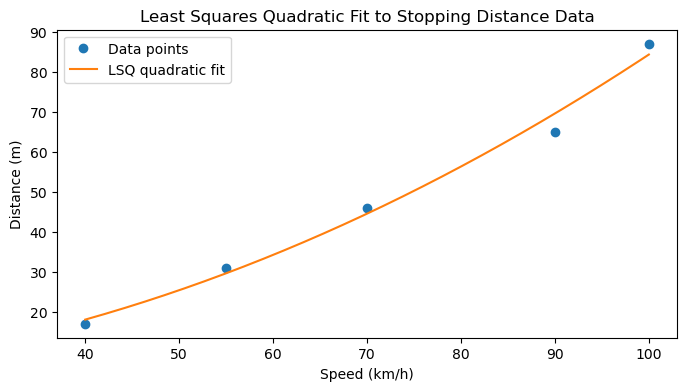

In [3]:
import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(8, 4))
plt.plot(speed, distance, 'o', label='Data points')
speed_fit = np.linspace(speed.min(), speed.max(), 200)
distance_fit = coeffs[0] + coeffs[1] * speed_fit + coeffs[2] * speed_fit**2
plt.plot(speed_fit, distance_fit, label='LSQ quadratic fit')
plt.xlabel('Speed (km/h)')
plt.ylabel('Distance (m)')
plt.title('Least Squares Quadratic Fit to Stopping Distance Data')
plt.legend()
plt.show()

**Task**
Look at the example in the book. They found that $a_0=0$, $a_1 = 0.1728$ and $a_2 = 0.0067$. Why?

Book polynomial coefficients: [0, 0.1728, 0.0067]
Our coefficients: [3.40125392 0.07016719 0.00738767]


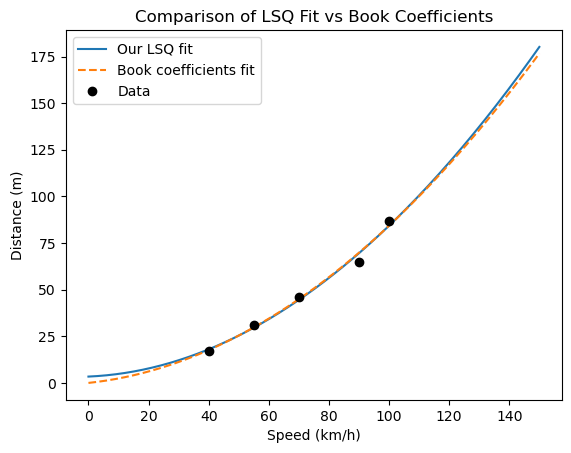

In [4]:
coeffs_poly_book = [0, 0.1728, 0.0067]
print("Book polynomial coefficients:", coeffs_poly_book)
print("Our coefficients:", coeffs)

x_arr = np.linspace(0, 150, 200)
# Fit curves using both sets of coefficients
y_manual = coeffs[0] + coeffs[1] * x_arr + coeffs[2] * x_arr**2
y_book = coeffs_poly_book[0] + coeffs_poly_book[1] * x_arr + coeffs_poly_book[2] * x_arr**2
plt.plot(x_arr, y_manual, label='Our LSQ fit')
plt.plot(x_arr, y_book, '--', label='Book coefficients fit')
plt.plot(speed, distance, 'ko', label='Data')

plt.xlabel('Speed (km/h)')
plt.ylabel('Distance (m)')
plt.title('Comparison of LSQ Fit vs Book Coefficients')
plt.legend()
plt.show()

**Solution**
Physically, the stopping distance must be zero at zero speed. The book therefore uses the model $g(x)=a_1x+a_2x^2$ without a constant term, i.e. the basis $\{x, x^2\}$. Removing the first column of $A$ reproduces the book's coefficients:

In [5]:
A_no_const = A[:, 1:]  # basis {x, x^2}
coeffs_no_const, *_ = np.linalg.lstsq(A_no_const, y_vec, rcond=None)
print("LSQ without constant term: a1 = %.4f, a2 = %.4f" % tuple(coeffs_no_const))

LSQ without constant term: a1 = 0.1728, a2 = 0.0067


## Example 14: **Continuous Least Squares Cubic Approximation to $\sin x$ on $[0, \pi]$**

We seek a cubic polynomial $p(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3$ that best approximates $\sin x$ on $[0, \pi]$ in the least squares sense. The coefficients minimize
$$
J({\bf a})=\int_0^\pi \left( \sin x - (a_0 + a_1 x + a_2 x^2 + a_3 x^3) \right)^2 dx
$$

The normal equations are:
$$
-\frac{1}{2}\frac{\partial J}{\partial a_k}=\int_0^\pi x^k \left( \sin x - \sum_{j=0}^3 a_j x^j \right) dx = 0, \quad k=0,1,2,3
$$

This leads to a linear system $G\mathbf{a} = \mathbf{b}$, where
- $g_{kj} = \int_0^\pi x^{k+j} dx$

- $b_k = \int_0^\pi x^k \sin x \, dx$

The solution gives the best cubic approximation in the $L^2$ sense. This approach can be implemented numerically using quadrature for the integrals and solving the resulting linear system for $a_0, a_1, a_2, a_3$.

In [6]:
from scipy.integrate import quad

# Gram matrix G and right-hand side b for the cubic approximation to sin(x) on [0, pi]
G_cont = np.zeros((4, 4))
b_cont = np.zeros(4)

for k in range(4):
    for j in range(4):
        G_cont[k, j], _ = quad(lambda x: x**(k + j), 0, np.pi)  # integral of x^(k+j) from 0 to pi
    b_cont[k], _ = quad(lambda x: x**k * np.sin(x), 0, np.pi)   # integral of x^k * sin(x) from 0 to pi

print("G matrix (continuous):\n", G_cont)
print("b vector (continuous):\n", b_cont)

G matrix (continuous):
 [[  3.14159265   4.9348022   10.33542556  24.35227276]
 [  4.9348022   10.33542556  24.35227276  61.20393696]
 [ 10.33542556  24.35227276  61.20393696 160.23153226]
 [ 24.35227276  61.20393696 160.23153226 431.47046111]]
b vector (continuous):
 [ 2.          3.14159265  5.8696044  12.15672076]


In [7]:
# Eigenvalues and condition number of the Gram matrix for the monomial basis
eigenvalues = np.linalg.eigvals(G_cont)
condition_number = np.linalg.cond(G_cont)

print("Eigenvalues of G:", eigenvalues)
print(f"Condition number of G: {condition_number:.1e}  -- already large for only 4 basis functions")

Eigenvalues of G: [5.01483907e+02 4.20389253e+00 4.47850074e-01 1.57668496e-02]
Condition number of G: 3.2e+04  -- already large for only 4 basis functions


The monomials $1, x, x^2, x^3$ look more and more alike as the power grows, so the columns of $G$ are nearly linearly dependent. (On $[0,1]$ this $G$ is the famous _Hilbert matrix_, whose condition number grows roughly like $e^{3.5 n}$.)

In [8]:
a = np.linalg.solve(G_cont, b_cont)  # solve for coefficients
print("Coefficients of LSQ cubic polynomial:", a)

Coefficients of LSQ cubic polynomial: [-5.04654978e-02  1.31223620e+00 -4.17697757e-01  1.85646222e-15]


**Observation:** $a_3 \approx 0$ (to rounding error), so the best _cubic_ is actually a quadratic!
The reason is symmetry: $\sin x$ is symmetric about $x=\pi/2$. Writing the cubic in powers of $(x-\pi/2)$, the odd terms are antisymmetric about $\pi/2$ and are orthogonal to $\sin x$ on $[0,\pi]$, so their coefficients vanish, and the $x^3$ term disappears with them.

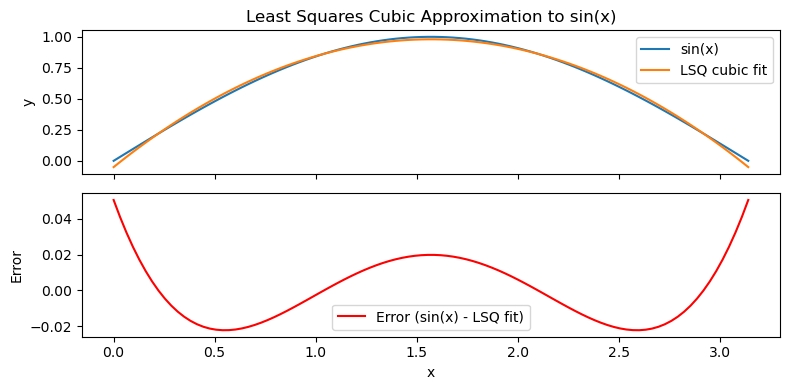

In [9]:
x=np.linspace(0, np.pi, 100)
y=np.sin(x)
Y_lsq=np.polyval(a[::-1], x)
fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Top: sin(x) and LSQ cubic fit
axs[0].plot(x, y, label='sin(x)')
axs[0].plot(x, Y_lsq, label='LSQ cubic fit')
axs[0].set_ylabel('y')
axs[0].set_title('Least Squares Cubic Approximation to sin(x)')
axs[0].legend()

# Bottom: Error
error = y - Y_lsq
axs[1].plot(x, error, color='r', label='Error (sin(x) - LSQ fit)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Error')
axs[1].legend()

plt.tight_layout()
plt.show()

**Task**
- What happens if you plot $\sin(x)$ and the polynomial for larger x-domain?
- Can you make the error smaller by using a higher degree polynomial? 

## Example: Least Squares with Ill-Conditioned Matrix

To demonstrate ill-conditioning, we sample 50 points from $\sin(x)$ on $[0, 2\pi]$, add noise, and fit a high-degree polynomial (here degree 15). The Vandermonde matrix $A$ becomes ill-conditioned, and $A^TA$ is even worse since $\kappa(A^TA)=\kappa(A)^2$.

We compare four ways of computing the same least squares polynomial:
1. `np.linalg.inv(A.T @ A) @ A.T @ y`: normal equations with an explicit inverse
2. `np.linalg.solve(A.T @ A, A.T @ y)`: normal equations with Gaussian elimination
3. `np.linalg.lstsq(A, y)`: QR/SVD on $A$ directly, never forms $A^TA$
4. `Chebyshev.fit(x, y, deg)`: an orthogonal polynomial basis on the scaled interval $[-1,1]$

Mathematically all four give the same polynomial. **Key check:** the exact least squares residual can never _increase_ when the degree increases (the larger polynomial space contains the smaller). A method whose residual grows with degree is suffering from rounding errors.

***Task*** Change the `deg` variable (try 5, 10, 12, 15, 20, 25) and see what happens. Which method breaks down first?

cond(A)     = 7.9e+04
cond(A^T A) = 6.2e+09
Residual norm, inv(A^T A)   : 1.990
Residual norm, solve(A^T A) : 1.990
Residual norm, lstsq(A)     : 1.990
Residual norm, Chebyshev    : 1.990


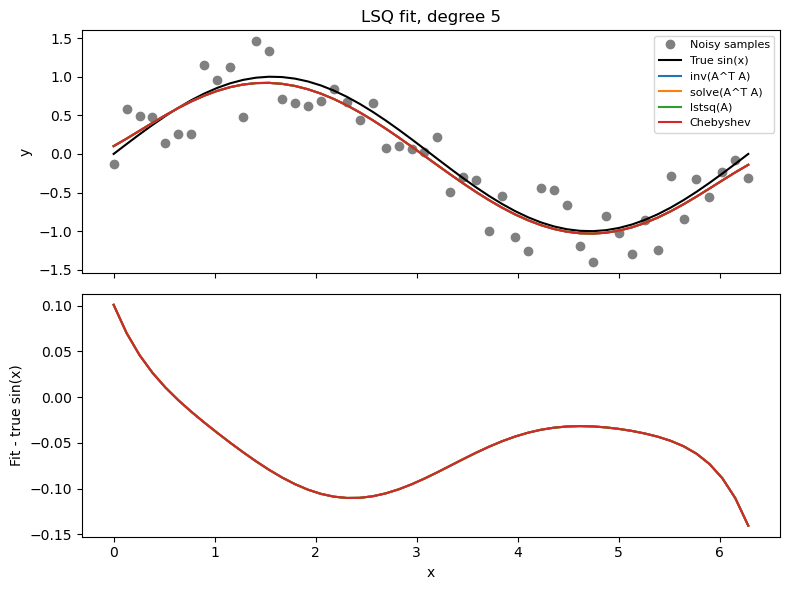

In [ ]:
from numpy.polynomial import Chebyshev

np.random.seed(42)

#change this line
deg = 5  # Degree of polynomial fit

n_points = 50  # Number of sample points
# Sample points from sin(x) with added uniform noise in [-0.5, 0.5]
x_sample = np.linspace(0, 2*np.pi, n_points)
y_sample = np.sin(x_sample)

noise_ramp = 5.e-1 # Noise 
noise = np.random.uniform(0, noise_ramp, size=n_points)
y_noisy = y_sample + 2*(noise - 0.5*noise_ramp)

# Vandermonde matrix: column p is x_sample**p, p = 0..deg
A_vander = np.stack([x_sample**p for p in range(deg + 1)], axis=1)
ATA = A_vander.T @ A_vander
ATy = A_vander.T @ y_noisy

fits = {
    'inv(A^T A)':   A_vander @ (np.linalg.inv(ATA) @ ATy),
    'solve(A^T A)': A_vander @ np.linalg.solve(ATA, ATy),
    'lstsq(A)':     A_vander @ np.linalg.lstsq(A_vander, y_noisy, rcond=None)[0],
    'Chebyshev':    Chebyshev.fit(x_sample, y_noisy, deg)(x_sample),
}

print(f"cond(A)     = {np.linalg.cond(A_vander):.1e}")
print(f"cond(A^T A) = {np.linalg.cond(ATA):.1e}")
for name, y_fit in fits.items():
    print(f"Residual norm, {name:13s}: {np.linalg.norm(y_fit - y_noisy):.3f}")

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(x_sample, y_noisy, 'o', color='gray', label='Noisy samples')
axs[0].plot(x_sample, y_sample, 'k', label='True sin(x)')
for name, y_fit in fits.items():
    axs[0].plot(x_sample, y_fit, label=name)
axs[0].set_ylabel('y')
axs[0].set_title(f'LSQ fit, degree {deg}')
axs[0].legend(fontsize=8)

for name, y_fit in fits.items():
    axs[1].plot(x_sample, y_fit - y_sample, label=name)
axs[1].set_xlabel('x')
axs[1].set_ylabel('Fit - true sin(x)')

plt.tight_layout()
plt.show()

## Example overfitting
This interactive Plotly visualization demonstrates polynomial least squares fitting and the concept of overfitting. Synthetic noisy data is generated from a quadratic function, and polynomial models of degrees 1 through 15 are fit to the data. The slider allows you to select the polynomial degree and observe how the fit changes:

- **Low-degree polynomials** (e.g., degree 1 or 2) may underfit the data, failing to capture its curvature.
- **Higher-degree polynomials** can fit the training data very closely, but may exhibit large oscillations and poor generalization outside the data range—this is known as overfitting.
- The true underlying function is shown for comparison.

**Task:** Use the slider to explore how increasing the polynomial degree affects the fit and the risk of overfitting.

Below the slider plot, the error on the training data and on new test data from the same model is shown as a function of degree.

In [20]:
import numpy as np
import plotly.graph_objects as go

# Generate synthetic data
np.random.seed(0)
x = np.linspace(-3, 3, 30)
true_y = 0.5 * x**2 + x + 2
noise = np.random.normal(0, 1, size=x.shape)
y = true_y + noise

# x-values for model prediction
x_fit = np.linspace(-3.5, 3.5, 300)

# Fit models of degree 1 to 15
traces = []
for deg in range(1, 16):
    coefs = np.polyfit(x, y, deg)
    y_fit = np.polyval(coefs, x_fit)
    trace = go.Scatter(x=x_fit, y=y_fit, name=f'Degree {deg}', visible=(deg == 2))
    traces.append(trace)

# Training data and true function
scatter_data = go.Scatter(x=x, y=y, mode='markers', name='Training Data', marker=dict(color='blue'))
true_func = go.Scatter(x=x_fit, y=0.5 * x_fit**2 + x_fit + 2, mode='lines',
                       name='True function', line=dict(dash='dot', color='green'))

# Set up the figure
fig = go.Figure(data=[scatter_data, true_func] + traces)

# Slider steps
steps = []
for i in range(15):
    step = dict(
        method='update',
        args=[{'visible': [True, True] + [j == i for j in range(15)]},
              {'title': f'Least Squares Fit - Polynomial Degree {i+1}'}],
        label=f'{i+1}'
    )
    steps.append(step)

# Add slider
sliders = [dict(
    active=1,
    currentvalue={"prefix": "Polynomial Degree: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    title='Least Squares Fit - Polynomial Degree 2',
    xaxis_title='x',
    yaxis_title='y',
    legend_title='Explanation'
)
fig.update_yaxes(range=[-3, 10])
fig.show()

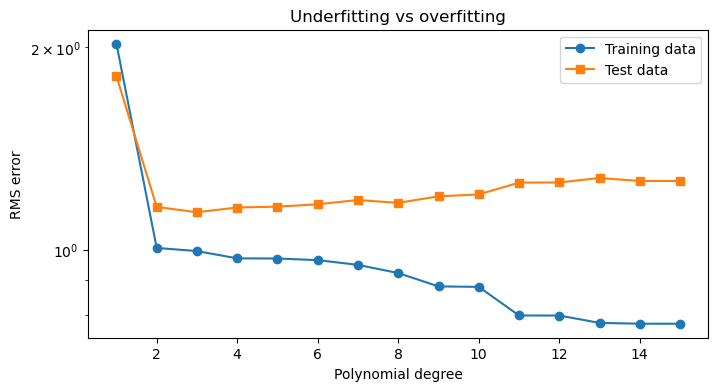

In [22]:
# Training error vs test error as a function of degree
np.random.seed(1)
x_test = np.random.uniform(-3, 3, 200)
y_test = 0.5 * x_test**2 + x_test + 2 + np.random.normal(0, 1, size=x_test.shape)

degrees = range(1, 16)
rms_train, rms_test = [], []
for deg in degrees:
    coefs = np.polyfit(x, y, deg)
    rms_train.append(np.sqrt(np.mean((np.polyval(coefs, x) - y)**2)))
    rms_test.append(np.sqrt(np.mean((np.polyval(coefs, x_test) - y_test)**2)))

plt.figure(figsize=(8, 4))
plt.semilogy(degrees, rms_train, 'o-', label='Training data')
plt.semilogy(degrees, rms_test, 's-', label='Test data')
plt.xlabel('Polynomial degree')
plt.ylabel('RMS error')
plt.title('Underfitting vs overfitting')
plt.legend()
plt.show()

## Example Continuous LSQ
Given the function:
$f(x)= 5 \sin(x)+2\cos(2x)$ for $x\in[0,2\pi]$.
We aim to approximate this function with a polynomial of degree 4 (`dim = 5` basis functions $1, x, \ldots, x^4$).

Condition number of G (monomial basis): 5.3e+07


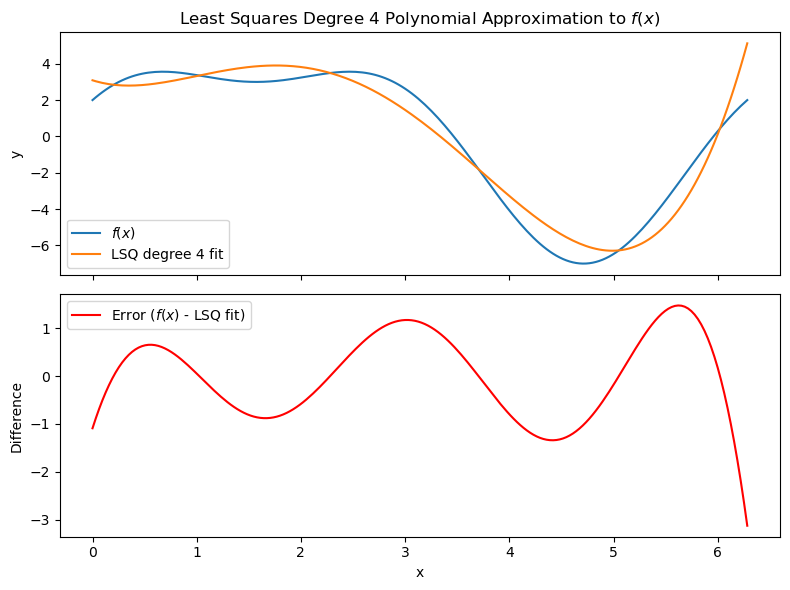

In [13]:
f = lambda x: 5*np.sin(x) + 2*np.cos(2*x)  # function to approximate
L = 2*np.pi  # interval [0, L]

# Gram matrix and right-hand side for the monomial basis
dim = 5
G_cont = np.zeros((dim, dim))
b_cont = np.zeros(dim)

for k in range(dim):
    for j in range(dim):
        G_cont[k, j], _ = quad(lambda x: x**(k + j), 0, L)
    b_cont[k], _ = quad(lambda x: x**k * f(x), 0, L)

coeffs = np.linalg.solve(G_cont, b_cont)

print(f"Condition number of G (monomial basis): {np.linalg.cond(G_cont):.1e}")
x_plot = np.linspace(0, L, 200)
y_true = f(x_plot)
y_lsq = np.polyval(coeffs[::-1], x_plot)

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(x_plot, y_true, label='$f(x)$')
axs[0].plot(x_plot, y_lsq, label=f'LSQ degree {dim-1} fit')
axs[0].set_ylabel('y')
axs[0].set_title(f'Least Squares Degree {dim-1} Polynomial Approximation to $f(x)$')
axs[0].legend()

axs[1].plot(x_plot, y_true - y_lsq, color='r', label='Error ($f(x)$ - LSQ fit)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Difference')
axs[1].legend()

plt.tight_layout()
plt.show()

### Using Fourier basis
Repeat the example above using Fourier polynomials. 
The Fourier basis up to degree 5 consists of the following functions:
- $\displaystyle 1$
- $\displaystyle \sin(x)$, $\cos(x)$
- $\displaystyle \sin(2x)$, $\cos(2x)$
- $\displaystyle \sin(3x)$, $\cos(3x)$
- $\displaystyle \sin(4x)$, $\cos(4x)$
- $\displaystyle \sin(5x)$, $\cos(5x)$

Or, as a sum:
$$
g(x) = a_0 + \sum_{k=1}^{5} \left[ a_{2k-1} \sin(kx) + a_{2k} \cos(kx) \right]
$$

In total, this gives $2 \times 5 + 1 = 11$ basis functions. The least squares fit finds the best coefficients for each basis function to approximate the target function over the interval $[0, 2\pi]$.

G (Fourier basis):
 [[ 6.28  0.    0.   -0.   -0.    0.   -0.   -0.   -0.   -0.   -0.  ]
 [ 0.    3.14 -0.    0.    0.    0.   -0.   -0.   -0.   -0.    0.  ]
 [ 0.   -0.    3.14  0.   -0.   -0.    0.   -0.   -0.    0.   -0.  ]
 [-0.    0.    0.    3.14 -0.    0.   -0.    0.    0.   -0.    0.  ]
 [-0.    0.   -0.   -0.    3.14 -0.   -0.    0.   -0.    0.   -0.  ]
 [ 0.    0.   -0.    0.   -0.    3.14  0.    0.    0.   -0.    0.  ]
 [-0.   -0.    0.   -0.   -0.    0.    3.14  0.   -0.    0.   -0.  ]
 [-0.   -0.   -0.    0.    0.    0.    0.    3.14  0.   -0.   -0.  ]
 [-0.   -0.   -0.    0.   -0.    0.   -0.    0.    3.14 -0.   -0.  ]
 [-0.   -0.    0.   -0.    0.   -0.    0.   -0.   -0.    3.14  0.  ]
 [-0.    0.   -0.    0.   -0.    0.   -0.   -0.   -0.    0.    3.14]]
Condition number of G (Fourier basis): 2.00
coeffs_fourier: [-0.  5.  0.  0.  2. -0.  0. -0.  0. -0.  0.]


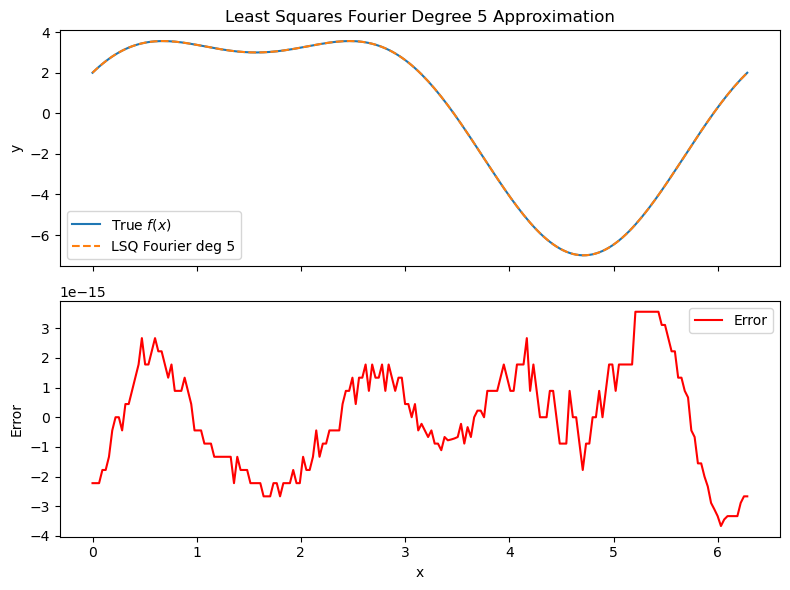

In [14]:
# Fourier basis: [1, sin(x), cos(x), sin(2x), cos(2x), ...] up to degree deg_fourier
deg_fourier = 5
basis_funcs = [lambda x: np.ones_like(x)]
for k in range(1, deg_fourier + 1):
    basis_funcs.append(lambda x, k=k: np.sin(k * x))
    basis_funcs.append(lambda x, k=k: np.cos(k * x))

n_basis = len(basis_funcs)
G_fourier = np.zeros((n_basis, n_basis))
b_fourier = np.zeros(n_basis)

# Integrate over [0, 2*pi]
for i, phi_i in enumerate(basis_funcs):
    for j, phi_j in enumerate(basis_funcs):
        G_fourier[i, j], _ = quad(lambda x: phi_i(x) * phi_j(x), 0, 2 * np.pi)
    b_fourier[i], _ = quad(lambda x: f(x) * phi_i(x), 0, 2 * np.pi)

np.set_printoptions(precision=2, suppress=True)
print("G (Fourier basis):\n", G_fourier)
np.set_printoptions()
print(f"Condition number of G (Fourier basis): {np.linalg.cond(G_fourier):.2f}")

coeffs_fourier = np.linalg.solve(G_fourier, b_fourier)
print("coeffs_fourier:", np.round(coeffs_fourier, 12))

# Evaluate Fourier fit on [0, 2*pi]
x_plot = np.linspace(0, 2 * np.pi, 200)
y_true = f(x_plot)
y_fourier_lsq = sum(c * phi(x_plot) for c, phi in zip(coeffs_fourier, basis_funcs))

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(x_plot, y_true, label='True $f(x)$')
axs[0].plot(x_plot, y_fourier_lsq, '--', label=f'LSQ Fourier deg {deg_fourier}')
axs[0].set_ylabel('y')
axs[0].set_title(f'Least Squares Fourier Degree {deg_fourier} Approximation')
axs[0].legend()

axs[1].plot(x_plot, y_true - y_fourier_lsq, color='r', label='Error')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Error')
axs[1].legend()

plt.tight_layout()
plt.show()

**Observations**
- $G$ is _diagonal_ ($2\pi$ for the constant, $\pi$ for the others): the Fourier basis is orthogonal on $[0,2\pi]$. The condition number is 2, compared to about $5\cdot 10^{7}$ for the monomial basis above.
- Each coefficient is therefore found independently, $a_k = b_k/g_{kk}$. These are exactly the Fourier coefficients.
- Here $f$ lies in the span of the basis, so LSQ recovers $5$ and $2$ exactly and the error is at rounding level.

**Tasks**
- Play with the lambda function `f` and confirm that the LSQ gives reasonable results. Try a function that is _not_ in the span of the basis, e.g. $f(x)=x$ or $f(x)=e^{-x}$. What happens if you add some random noise to the function?
- Can you repeat the examples using _scipy_/_numpy_ routines (`np.polyfit`, `np.linalg.lstsq`, `scipy.linalg.lstsq`)?

## Summary
- Least squares with a linear combination of basis functions leads to the **normal equations**: $A^TA\,{\bf a}=A^T{\bf y}$ (discrete) or $G\,{\bf a}={\bf b}$ with the Gram matrix $g_{jk}=\int\phi_j\phi_k\,dx$ (continuous).
- The **monomial basis** gives badly conditioned systems, and forming $A^TA$ squares the condition number. Never use the explicit inverse. Prefer QR/SVD-based solvers (`np.linalg.lstsq`, `np.polyfit`) and, for high degrees, a better basis.
- An **orthogonal basis** (Fourier, Legendre, ...) gives a diagonal Gram matrix: well conditioned, and each coefficient is computed independently.
- A higher degree always reduces the error on the data, but beyond a point it **overfits**: the error on new data increases.